In [1]:
"""
GUNDAM Realistic Example
========================
6 truth bins × 10 reco bins (A-J)
12 parameters total:
  - 10 template parameters  (c0...c9)  — one per truth bin, unconstrained
  - 3 flux systematics     (f_low, f_mid, f_high) — ±10% Gaussian prior
  - 3 detector systematics (d_low, d_mid, d_high) — ±5%  Gaussian prior

Background types: RES, DIS, CCother, NC, Cosmic
"""

import numpy as np
from scipy.optimize import minimize
from scipy.linalg import cholesky
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

print("=" * 70)
print("GUNDAM REALISTIC EXAMPLE")
print("10 Truth Bins | 20 Reco Bins | 10 Templates + 3 Flux + 3 Detector Syst")
print("=" * 70)

GUNDAM REALISTIC EXAMPLE
10 Truth Bins | 20 Reco Bins | 10 Templates + 3 Flux + 3 Detector Syst


In [2]:
# ============================================================================
# STEP 1: KINEMATICS & BINNING
# ============================================================================

true_bin_edges  = np.arange(0.0, 2.1, 0.2)
true_bin_widths = np.diff(true_bin_edges)

reco_bin_edges  = np.arange(0.0, 2.1, 0.1)
reco_bin_widths = np.diff(reco_bin_edges)
reco_bin_labels = [chr(65 + i) for i in range(20)]  # A–T

# Truth bin table
print("Truth Bins")
print(f"{'Bin':>5}  {'Range (GeV/c)':>16}  {'Width':>8}")
print("-" * 35)
for i in range(len(true_bin_edges) - 1):
    print(f"  T{i+1}    [{true_bin_edges[i]:.2f}, {true_bin_edges[i+1]:.2f}]      {true_bin_widths[i]:.2f}")

print()

# Reco bins table
print("Reco Bins")
print(f"{'Bin':>5}  {'Range (GeV/c)':>16}  {'Width':>8}  {'Truth Bin':>10}")
print("-" * 50)
for j in range(len(reco_bin_edges) - 1):
    truth_idx = j // 2 + 1
    print(f"  {reco_bin_labels[j]}     [{reco_bin_edges[j]:.2f}, {reco_bin_edges[j+1]:.2f}]      {reco_bin_widths[j]:.2f}        T{truth_idx}")

Truth Bins
  Bin     Range (GeV/c)     Width
-----------------------------------
  T1    [0.00, 0.20]      0.20
  T2    [0.20, 0.40]      0.20
  T3    [0.40, 0.60]      0.20
  T4    [0.60, 0.80]      0.20
  T5    [0.80, 1.00]      0.20
  T6    [1.00, 1.20]      0.20
  T7    [1.20, 1.40]      0.20
  T8    [1.40, 1.60]      0.20
  T9    [1.60, 1.80]      0.20
  T10    [1.80, 2.00]      0.20

Reco Bins
  Bin     Range (GeV/c)     Width   Truth Bin
--------------------------------------------------
  A     [0.00, 0.10]      0.10        T1
  B     [0.10, 0.20]      0.10        T1
  C     [0.20, 0.30]      0.10        T2
  D     [0.30, 0.40]      0.10        T2
  E     [0.40, 0.50]      0.10        T3
  F     [0.50, 0.60]      0.10        T3
  G     [0.60, 0.70]      0.10        T4
  H     [0.70, 0.80]      0.10        T4
  I     [0.80, 0.90]      0.10        T5
  J     [0.90, 1.00]      0.10        T5
  K     [1.00, 1.10]      0.10        T6
  L     [1.10, 1.20]      0.10        T6
  M     

In [3]:
# ============================================================================
# STEP 2: SYSTEMATICS SETUP
# ============================================================================

# Parameter ordering:
#   [0..9]   → template parameters c1..c10  (one per truth bin, no prior)
#   [10]     → f_low   (flux, truth bins T1–T3)
#   [11]     → f_mid   (flux, truth bins T4–T7)
#   [12]     → f_high  (flux, truth bins T8–T10)
#   [13]     → d_low   (detector, reco bins A–H)
#   [14]     → d_mid   (detector, reco bins I–P)
#   [15]     → d_high  (detector, reco bins Q–T)

n_templates = len(true_bin_edges) - 1    # 10
n_syst      = 6                          # 3 flux + 3 detector
n_params    = n_templates + n_syst       # 16

param_names = [f'c{i+1}' for i in range(n_templates)] + \
              ['f_low', 'f_mid', 'f_high', 'd_low', 'd_mid', 'd_high']

# Bounds: c_i > 0, systematics unconstrained
bounds = [(1e-4, None)] * n_templates + [(None, None)] * n_syst

priors = np.zeros(n_params)
sigmas = np.array([
    *[1e6] * n_templates,   # templates: unconstrained
    0.10, 0.10, 0.10,       # flux: ±10%
    0.05, 0.05, 0.05,       # detector: ±5%
])

# Which truth bins each flux parameter affects (indices)
flux_bins = {
    10: [0, 1, 2],          # f_low  → T1, T2, T3
    11: [3, 4, 5, 6],       # f_mid  → T4, T5, T6, T7
    12: [7, 8, 9],          # f_high → T8, T9, T10
}

# Which reco bins each detector parameter affects (indices)
det_bins = {
    13: list(range(0,  8)),  # d_low  → A–H
    14: list(range(8,  16)), # d_mid  → I–P
    15: list(range(16, 20)), # d_high → Q–T
}

print(f"{'Parameter':<12} {'Prior':>8} {'Sigma':>10}")
print("-" * 34)
for k, name in enumerate(param_names):
    sigma_str = f"±{sigmas[k]*100:.0f}%" if sigmas[k] < 1e5 else "free"
    print(f"  {name:<10}  {priors[k]:>+6.2f}  {sigma_str:>10}")

Parameter       Prior      Sigma
----------------------------------
  c1           +0.00        free
  c2           +0.00        free
  c3           +0.00        free
  c4           +0.00        free
  c5           +0.00        free
  c6           +0.00        free
  c7           +0.00        free
  c8           +0.00        free
  c9           +0.00        free
  c10          +0.00        free
  f_low        +0.00        ±10%
  f_mid        +0.00        ±10%
  f_high       +0.00        ±10%
  d_low        +0.00         ±5%
  d_mid        +0.00         ±5%
  d_high       +0.00         ±5%


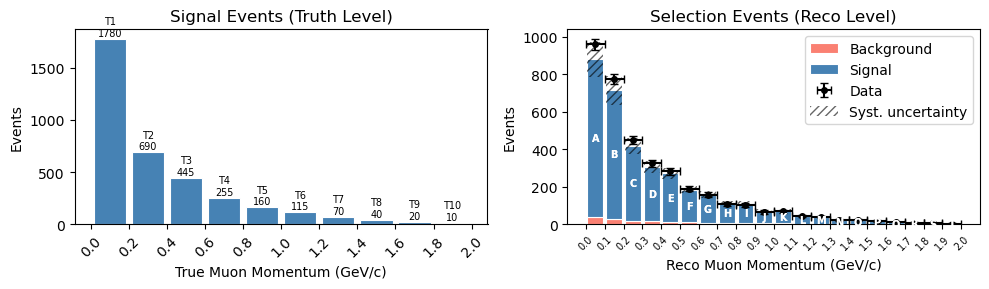

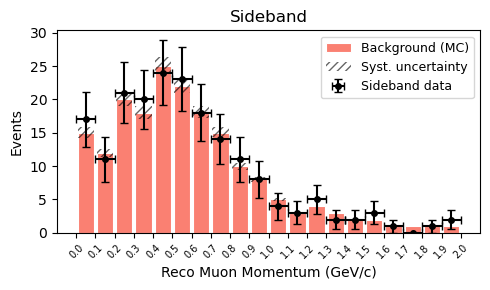

In [4]:
# ============================================================================
# STEP 3: MC INPUTS
# ============================================================================

# Truth-level counts — falling distribution matching ROOT histogram
N_true_gen = np.array([1780., 690., 445., 255., 160., 115., 70., 40., 20., 10.])

# 10x20 migration matrix — 2 reco bins per truth bin, diagonal dominant
N_ij = np.array([
    # A      B      C      D      E      F      G      H      I      J      K      L      M      N      O      P      Q      R      S      T
    [800.,  650.,   80.,   20.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T1
    [ 40.,   30.,  300.,  250.,   30.,   10.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T2
    [  0.,    5.,   20.,   15.,  220.,  150.,   20.,   10.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T3
    [  0.,    0.,    0.,    5.,   10.,   10.,  120.,   80.,   15.,    5.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T4
    [  0.,    0.,    0.,    0.,    0.,    5.,   10.,   10.,   80.,   50.,   10.,    5.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],  # T5
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    5.,   10.,   10.,   55.,   30.,    5.,    2.,    0.,    0.,    0.,    0.,    0.,    0.],  # T6
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    5.,    5.,    5.,   30.,   15.,    5.,    2.,    0.,    0.,    0.,    0.],  # T7
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    3.,    3.,    3.,   15.,   10.,    2.,    1.,    0.,    0.],  # T8
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    2.,    2.,    2.,    6.,    4.,    1.,    0.],  # T9
    [  0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    2.,    1.,    1.,    2.,    2.],  # T10
], dtype=float)

eff = N_ij.sum(axis=1) / N_true_gen

B_j    = np.array([40., 30., 18., 15., 12., 10., 8., 7., 6., 5., 4., 3., 3., 2., 2., 2., 1., 1., 1., 1.])
B_type = ['RES','RES','RES','RES','DIS','DIS','DIS','DIS','CCother','CCother',
          'CCother','CCother','NC','NC','NC','NC','Cosmic','Cosmic','Cosmic','Cosmic']

N_mc_signal = N_ij.sum(axis=0)
N_mc_total  = N_mc_signal + B_j
N_data      = N_mc_total # ASIMOV Fake Data
N_data      = N_mc_total + np.array([80., 60., 30., 20., 10., 5., 0., -5., -10., -10.,
                                 -5., -3., -2., -1., -1., -1.,  0.,  0.,  0.,  0.])

# ── Histograms ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Left: Truth-level signal
ax = axes[0]
true_centers = 0.5 * (true_bin_edges[:-1] + true_bin_edges[1:])
ax.bar(true_centers, N_true_gen, width=true_bin_widths * 0.85,
       color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xlabel('True Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Signal Events (Truth Level)')
ax.set_xticks(true_bin_edges)
ax.tick_params(axis='x', rotation=45)
for i, (x, y) in enumerate(zip(true_centers, N_true_gen)):
    ax.text(x, y + 10, f'T{i+1}\n{int(y)}', ha='center', va='bottom', fontsize=7)

# Right: Reco-level selection
ax = axes[1]
reco_centers = 0.5 * (reco_bin_edges[:-1] + reco_bin_edges[1:])
ax.bar(reco_centers, B_j, width=reco_bin_widths * 0.85,
       color='salmon', edgecolor='white', linewidth=0.8, label='Background')
ax.bar(reco_centers, N_mc_signal, width=reco_bin_widths * 0.85,
       bottom=B_j, color='steelblue', edgecolor='white', linewidth=0.8, label='Signal')
ax.errorbar(reco_centers, N_data, yerr=np.sqrt(N_data), xerr=reco_bin_widths / 2,
            fmt='ko', markersize=4, capsize=3, label='Data')
ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Selection Events (Reco Level)')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
for j, (x, sig, bkg) in enumerate(zip(reco_centers, N_mc_signal, B_j)):
    ax.text(x, bkg + sig / 2, reco_bin_labels[j], ha='center', va='center',
            fontsize=7, color='white', fontweight='bold')

# ── Pre-fit systematic uncertainty band ──────────────────────────────────────
n_band_toys = 2000
flux_groups = [list(range(0, 6)), list(range(6, 14)), list(range(14, 20))]
det_groups  = [list(range(0, 8)), list(range(8, 16)), list(range(16, 20))]
pred_toys   = np.zeros((n_band_toys, len(reco_bin_edges) - 1))
for k in range(n_band_toys):
    f      = np.random.normal(0, 0.10, size=3)
    d      = np.random.normal(0, 0.05, size=3)
    flux_w = np.ones(len(reco_bin_edges) - 1)
    det_w  = np.ones(len(reco_bin_edges) - 1)
    for g in range(3):
        flux_w[flux_groups[g]] *= (1 + f[g])
        det_w[det_groups[g]]   *= (1 + d[g])
    pred_toys[k] = N_mc_signal * flux_w * det_w + B_j
pred_mean = np.mean(pred_toys, axis=0)
pred_std  = np.std(pred_toys,  axis=0)
ax.bar(reco_centers, 2 * pred_std, width=reco_bin_widths * 0.85,
       bottom=pred_mean - pred_std,
       color='none', edgecolor='black', linewidth=0,
       hatch='////', alpha=0.6, label='Syst. uncertainty')
# ─────────────────────────────────────────────────────────────────────────────

for j, (x, sig, bkg) in enumerate(zip(reco_centers, N_mc_signal, B_j)):
    ax.text(x, bkg + sig / 2, reco_bin_labels[j], ha='center', va='center',
            fontsize=7, color='white', fontweight='bold')

ax.legend()

plt.tight_layout()
plt.show()

# Sideband: same reco bins, but signal-free (e.g. events with pions)
B_sb      = np.array([15., 12., 20., 18., 25., 22., 18., 15., 10., 8., 5., 3., 4., 3., 2., 2., 1., 1., 1., 1.])
B_sb_type = ['RES','RES','RES','RES','DIS','DIS','DIS','DIS','CCother','CCother',
             'CCother','CCother','NC','NC','NC','NC','Cosmic','Cosmic','Cosmic','Cosmic']
N_sb_data = B_sb + np.array([2.,-1.,1.,2.,-1.,1.,0.,-1.,1.,0.,-1.,0.,1.,-1.,0.,1.,0.,-1.,0.,1.])

sb_centers = reco_centers
sb_widths  = reco_bin_widths
det_groups = [list(range(0, 8)), list(range(8, 16)), list(range(16, 20))]

sb_centers = reco_centers[:len(B_sb)]
sb_widths  = reco_bin_widths[:len(B_sb)]

# Pre-fit sideband uncertainty band (detector systematics only)
n_sb_toys    = 2000
sb_pred_toys = np.zeros((n_sb_toys, len(B_sb)))
det_groups   = [list(range(0, 4)), list(range(4, 8)), list(range(8, 12))]

for k in range(n_sb_toys):
    d     = np.random.normal(0, 0.05, size=3)
    det_w = np.ones(len(B_sb))
    for g in range(3):
        det_w[det_groups[g]] *= (1 + d[g])
    sb_pred_toys[k] = B_sb * det_w

sb_pred_mean = np.mean(sb_pred_toys, axis=0)
sb_pred_std  = np.std(sb_pred_toys,  axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(sb_centers, B_sb, width=sb_widths * 0.85,
       color='salmon', edgecolor='white', linewidth=0.8, label='Background (MC)')
ax.bar(sb_centers, 2 * sb_pred_std, width=sb_widths * 0.85,
       bottom=sb_pred_mean - sb_pred_std,
       color='none', edgecolor='black', linewidth=0,
       hatch='////', alpha=0.6, label='Syst. uncertainty')
ax.errorbar(sb_centers, N_sb_data, yerr=np.sqrt(N_sb_data), xerr=sb_widths / 2,
            fmt='ko', markersize=4, capsize=3, label='Sideband data')

ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Sideband')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================================
# STEP 4: FORWARD MODEL
# ============================================================================

def forward_model(params):
    """
    Predict reco-level event counts given all 16 parameters.

    1. Each truth bin i scaled by template c_i
    2. Flux weight applied per truth-bin group
    3. Response matrix projects to reco space
    4. Detector weight applied per reco-bin group
    5. Background added (fixed)
    """
    c      = params[:n_templates]
    f_low, f_mid, f_high = params[n_templates:n_templates+3]
    d_low, d_mid, d_high = params[n_templates+3:n_templates+6]

    # Flux weight vector (one per truth bin)
    flux_w = np.array([
        1+f_low,  1+f_low,  1+f_low,   # T1–T3
        1+f_mid,  1+f_mid,  1+f_mid, 1+f_mid,  # T4–T7
        1+f_high, 1+f_high, 1+f_high,  # T8–T10
    ])

    # Detector weight vector (one per reco bin)
    det_w = np.array([
        *[1+d_low]  * 8,   # A–H
        *[1+d_mid]  * 8,   # I–P
        *[1+d_high] * 4,   # Q–T
    ])

    # Project truth → reco
    N_signal = np.zeros(len(reco_bin_edges) - 1)
    for i in range(n_templates):
        N_signal += c[i] * flux_w[i] * N_ij[i, :]

    return N_signal * det_w + B_j

# Test at nominal (all c=1, all syst=0)
params_init    = np.ones(n_params)
params_init[n_templates:] = 0.0
N_pred_init    = forward_model(params_init)

print(f"Nominal prediction: {np.round(N_pred_init, 1)}")
print(f"Observed data:      {N_data.astype(int)}")

# ============================================================================
# STEP 2.6: SIDEBAND FIT
# ============================================================================

def forward_model_sideband(params):
    d_low, d_mid, d_high = params[n_templates+3], params[n_templates+4], params[n_templates+5]
    det_w = np.array([
        *[1+d_low]  * 8,
        *[1+d_mid]  * 8,
        *[1+d_high] * 4,
    ])
    return B_sb * det_w

def neg_log_likelihood_sideband(params):
    N_pred = forward_model_sideband(params)
    L_stat = 0.0
    for j in range(len(B_sb)):
        if N_pred[j] > 0 and N_sb_data[j] > 0:
            L_stat += 2.0 * (N_pred[j] - N_sb_data[j] + N_sb_data[j] * np.log(N_sb_data[j] / N_pred[j]))
        elif N_pred[j] > 0:
            L_stat += 2.0 * N_pred[j]
    # Gaussian penalties on detector systematics only
    for k in [n_templates+3, n_templates+4, n_templates+5]:
        L_penalty = ((params[k] - priors[k]) / sigmas[k]) ** 2
        L_stat += L_penalty
    return L_stat

# Fit sideband
result_sb   = minimize(neg_log_likelihood_sideband, params_init,
                       method='L-BFGS-B', bounds=bounds)
params_sb   = result_sb.x

print(f"Sideband fit converged: {result_sb.success}")
print()
print(f"{'Parameter':<12} {'Pre-fit':>10} {'Post-fit (SB)':>15} {'Pull (σ)':>10}")
print("-" * 52)
for k in range(n_templates, n_params):
    name = param_names[k]
    pull = (params_sb[k] - priors[k]) / sigmas[k]
    print(f"  {name:<10}  {priors[k]:>+10.4f}  {params_sb[k]:>+15.4f}  {pull:>+10.2f}σ")

Nominal prediction: [880. 715. 418. 305. 272. 185. 158. 112. 111.  75.  74.  46.  41.  24.
  24.  18.  10.   7.   4.   3.]
Observed data:      [960 775 448 325 282 190 158 107 101  65  69  43  39  23  23  17  10   7
   4   3]
Sideband fit converged: True

Parameter       Pre-fit   Post-fit (SB)   Pull (σ)
----------------------------------------------------
  f_low          +0.0000          +0.0000       +0.00σ
  f_mid          +0.0000          +0.0000       +0.00σ
  f_high         +0.0000          +0.0000       +0.00σ
  d_low          +0.0000          +0.0055       +0.11σ
  d_mid          +0.0000          +0.0023       +0.05σ
  d_high         +0.0000          -0.0000       -0.00σ


In [6]:
# ============================================================================
# STEP 5: LIKELIHOOD
# ============================================================================

def neg_log_likelihood(params):
    """
    -2 log L = Poisson statistical term + Gaussian penalty for systematics
    """
    N_pred = forward_model(params)

    # Poisson log-likelihood (Baker-Cousins)
    L_stat = 0.0
    for j in range(len(reco_bin_edges) - 1):
        if N_pred[j] > 0 and N_data[j] > 0:
            L_stat += 2.0 * (N_pred[j] - N_data[j] + N_data[j] * np.log(N_data[j] / N_pred[j]))
        elif N_pred[j] > 0:
            L_stat += 2.0 * N_pred[j]

    # Gaussian penalties for syst parameters only
    L_penalty = 0.0
    for k in range(n_templates, n_params):
        L_penalty += ((params[k] - priors[k]) / sigmas[k]) ** 2

    return L_stat + L_penalty

L_init = neg_log_likelihood(params_init)
print(f"Initial -2logL: {L_init:.4f}")

Initial -2logL: 19.1847


In [7]:
# ============================================================================
# STEP 2.7: MAIN FIT STARTING FROM SIDEBAND-CONSTRAINED PARAMETERS
# ============================================================================

# Use sideband best-fit as starting point for main fit
# Nuisance parameters are already constrained by sideband
result_main = minimize(
    neg_log_likelihood,
    params_sb,                  # start from sideband best-fit
    method='L-BFGS-B',
    bounds=bounds,
    options={'ftol': 1e-12, 'gtol': 1e-8, 'maxiter': 10000}
)

params_best = result_main.x
L_best      = result_main.fun

print(f"Main fit converged: {result_main.success}")
print(f"Final -2logL: {L_best:.4f}")
print()
print(f"{'Parameter':<12} {'Pre-fit':>10} {'Post-fit (SB)':>15} {'Post-fit (Main)':>16} {'Pull (σ)':>10}")
print("-" * 68)
for k, name in enumerate(param_names):
    pull = (params_best[k] - priors[k]) / sigmas[k] if sigmas[k] < 1e5 else 0.
    pull_str = f"{pull:>+10.2f}σ" if sigmas[k] < 1e5 else f"{'(free)':>10}"
    print(f"  {name:<10}  {priors[k]:>+10.4f}  {params_sb[k]:>+15.4f}  {params_best[k]:>+16.4f}  {pull_str}")

N_pred_best = forward_model(params_best)

Main fit converged: True
Final -2logL: 0.2230

Parameter       Pre-fit   Post-fit (SB)  Post-fit (Main)   Pull (σ)
--------------------------------------------------------------------
  c1             +0.0000          +1.0000           +1.0939      (free)
  c2             +0.0000          +1.0000           +1.0727      (free)
  c3             +0.0000          +1.0000           +1.0364      (free)
  c4             +0.0000          +1.0000           +0.9878      (free)
  c5             +0.0000          +1.0000           +0.8598      (free)
  c6             +0.0000          +1.0000           +0.9351      (free)
  c7             +0.0000          +1.0000           +0.9466      (free)
  c8             +0.0000          +1.0000           +0.9344      (free)
  c9             +0.0000          +1.0000           +1.0224      (free)
  c10            +0.0000          +1.0000           +0.9825      (free)
  f_low          +0.0000          +0.0000           -0.0000       -0.00σ
  f_mid          +0.000

In [8]:
# ============================================================================
# STEP 6: FITTING
# ============================================================================

from scipy.optimize import minimize

result = minimize(
    neg_log_likelihood,
    params_init,
    method='L-BFGS-B',
    bounds=bounds,
    options={'ftol': 1e-12, 'gtol': 1e-8, 'maxiter': 10000}
)

params_best = result.x
L_best      = result.fun

print(f"Converged : {result.success}  ({result.message})")
print(f"Final -2logL: {L_best:.4f}  (improvement: {L_init - L_best:.2f})")
print()
print(f"{'Parameter':<12} {'Value':>10} {'Pull (σ)':>10}")
print("-" * 36)
for k, name in enumerate(param_names):
    val = params_best[k]
    if sigmas[k] < 1e5:
        pull = (val - priors[k]) / sigmas[k]
        print(f"  {name:<10}  {val:>+10.4f}  {pull:>+10.2f}σ")
    else:
        print(f"  {name:<10}  {val:>+10.4f}  {'(free)':>10}")

# Data vs best-fit comparison
N_pred_best = forward_model(params_best)
print()
print(f"{'Bin':<5} {'Data':>8} {'MC nominal':>12} {'Best-fit':>12} {'Residual':>10}")
print("-" * 52)
for j in range(len(reco_bin_edges) - 1):
    resid = (N_data[j] - N_pred_best[j]) / np.sqrt(N_data[j])
    print(f"  {reco_bin_labels[j]:<3}  {N_data[j]:>8.0f}  {N_pred_init[j]:>12.1f}  {N_pred_best[j]:>12.2f}  {resid:>+10.2f}")

Converged : True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
Final -2logL: 0.2230  (improvement: 18.96)

Parameter         Value   Pull (σ)
------------------------------------
  c1             +1.0939      (free)
  c2             +1.0727      (free)
  c3             +1.0364      (free)
  c4             +0.9878      (free)
  c5             +0.8598      (free)
  c6             +0.9351      (free)
  c7             +0.9466      (free)
  c8             +0.9344      (free)
  c9             +1.0224      (free)
  c10            +0.9825      (free)
  f_low          +0.0000       +0.00σ
  f_mid          -0.0000       -0.00σ
  f_high         +0.0000       +0.00σ
  d_low          -0.0008       -0.02σ
  d_mid          +0.0007       +0.01σ
  d_high         +0.0001       +0.00σ

Bin       Data   MC nominal     Best-fit   Residual
----------------------------------------------------
  A         960         880.0        957.27       +0.09
  B         775         715.0        777.78       -

Computing main fit Hessian...

Parameter        Best-fit    Uncertainty
------------------------------------------
  c1               +1.0939  ±      0.0889
  c2               +1.0727  ±      0.0923
  c3               +1.0364  ±      0.0924
  c4               +0.9878  ±      0.1000
  c5               +0.8598  ±      0.1033
  c6               +0.9351  ±      0.1186
  c7               +0.9466  ±      0.1519
  c8               +0.9344  ±      0.2168
  c9               +1.0224  ±      0.3382
  c10              +0.9825  ±      0.4729
  f_low            +0.0000  ±      0.0707
  f_mid            -0.0000  ±      0.0707
  f_high           +0.0000  ±      0.0707
  d_low            -0.0008  ±      0.0353
  d_mid            +0.0007  ±      0.0353
  d_high           +0.0001  ±      0.0353

Correlation matrix (templates c1–c10):
        T1     T2     T3     T4     T5     T6     T7     T8     T9     T10  
  T1     +1.00  +0.88  +0.87  +0.17  -0.03  +0.01  +0.00  -0.00  +0.00  +0.00
  T2     +0.88  +1

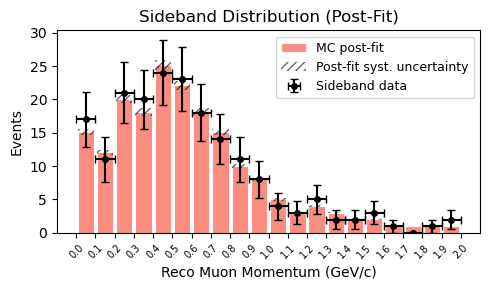

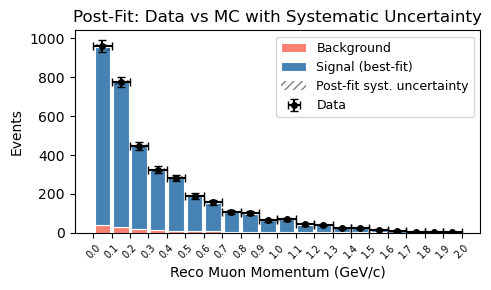

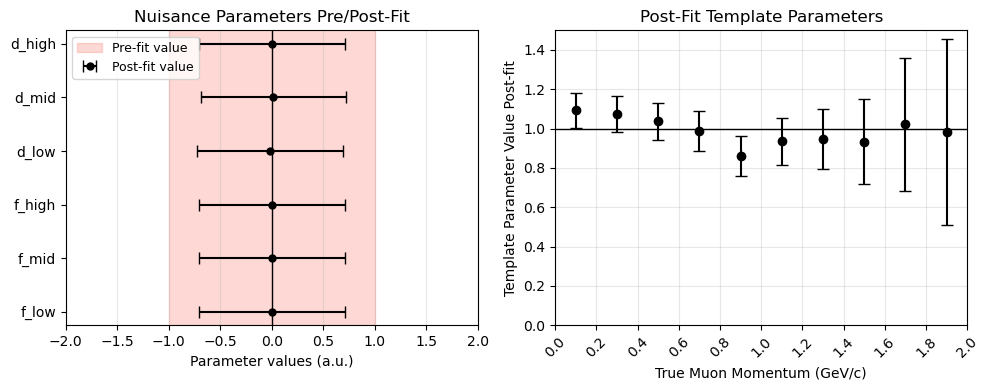

In [9]:
# ============================================================================
# STEP 7: HESSIAN & UNCERTAINTIES
# ============================================================================

eps = 1e-5

def compute_hessian_with(likelihood_fn, params, eps=1e-5):
    n  = len(params)
    H  = np.zeros((n, n))
    f0 = likelihood_fn(params)
    for i in range(n):
        for j in range(i, n):
            if i == j:
                p_p = params.copy(); p_p[i] += eps
                p_m = params.copy(); p_m[i] -= eps
                H[i,i] = (likelihood_fn(p_p) - 2*f0 + likelihood_fn(p_m)) / eps**2
            else:
                p_pp = params.copy(); p_pp[i] += eps; p_pp[j] += eps
                p_pm = params.copy(); p_pm[i] += eps; p_pm[j] -= eps
                p_mp = params.copy(); p_mp[i] -= eps; p_mp[j] += eps
                p_mm = params.copy(); p_mm[i] -= eps; p_mm[j] -= eps
                H[i,j] = (likelihood_fn(p_pp) - likelihood_fn(p_pm)
                         - likelihood_fn(p_mp) + likelihood_fn(p_mm)) / (4*eps**2)
                H[j,i] = H[i,j]
    return H

# ── Main fit Hessian ──────────────────────────────────────────────────────────
print("Computing main fit Hessian...")
H   = compute_hessian_with(neg_log_likelihood, params_best)
V   = np.linalg.inv(H)
err = np.sqrt(np.diag(V))

print(f"\n{'Parameter':<12} {'Best-fit':>12} {'Uncertainty':>14}")
print("-" * 42)
for k, name in enumerate(param_names):
    print(f"  {name:<10}  {params_best[k]:>+12.4f}  ±{err[k]:>12.4f}")

print("\nCorrelation matrix (templates c1–c10):")
print(f"{'':6}", end='')
for i in range(n_templates): print(f"  T{i+1:<4}", end='')
print()
for i in range(n_templates):
    print(f"  T{i+1:<4}", end='')
    for j in range(n_templates):
        rho = V[i,j] / (err[i] * err[j])
        print(f"  {rho:+.2f}", end='')
    print()

# ── Sideband Hessian — detector params only ───────────────────────────────────
print("\nComputing sideband Hessian (detector params only)...")
det_indices   = [n_templates+3, n_templates+4, n_templates+5]
det_params_sb = params_sb[det_indices].copy()
n_det         = len(det_indices)

def sb_likelihood_det_only(det_params):
    p = params_sb.copy()
    for k, idx in enumerate(det_indices):
        p[idx] = det_params[k]
    return neg_log_likelihood_sideband(p)

H_sb = np.zeros((n_det, n_det))
f0   = sb_likelihood_det_only(det_params_sb)
for i in range(n_det):
    for j in range(i, n_det):
        if i == j:
            p_p = det_params_sb.copy(); p_p[i] += eps
            p_m = det_params_sb.copy(); p_m[i] -= eps
            H_sb[i,i] = (sb_likelihood_det_only(p_p) - 2*f0
                        + sb_likelihood_det_only(p_m)) / eps**2
        else:
            p_pp = det_params_sb.copy(); p_pp[i] += eps; p_pp[j] += eps
            p_pm = det_params_sb.copy(); p_pm[i] += eps; p_pm[j] -= eps
            p_mp = det_params_sb.copy(); p_mp[i] -= eps; p_mp[j] += eps
            p_mm = det_params_sb.copy(); p_mm[i] -= eps; p_mm[j] -= eps
            H_sb[i,j] = (sb_likelihood_det_only(p_pp) - sb_likelihood_det_only(p_pm)
                        - sb_likelihood_det_only(p_mp) + sb_likelihood_det_only(p_mm)) / (4*eps**2)
            H_sb[j,i] = H_sb[i,j]

print(f"H_sb diagonal: {np.diag(H_sb)}")
V_sb = np.linalg.inv(H_sb)
L_sb = cholesky(V_sb, lower=True)

print("\nSideband post-fit detector uncertainties:")
for k, idx in enumerate(det_indices):
    print(f"  {param_names[idx]:<10}  {det_params_sb[k]:>+10.4f}  ±{np.sqrt(V_sb[k,k]):.4f}  (prior: ±{sigmas[idx]:.4f})")

# ── Sideband post-fit toys ────────────────────────────────────────────────────
n_sb_postfit_toys = 2000
sb_postfit_toys   = np.zeros((n_sb_postfit_toys, len(B_sb)))
for k in range(n_sb_postfit_toys):
    p       = params_sb.copy()
    det_toy = det_params_sb + L_sb @ np.random.randn(n_det)
    for m, idx in enumerate(det_indices):
        p[idx] = det_toy[m]
    for idx in [n_templates, n_templates+1, n_templates+2]:
        p[idx] = np.random.normal(0, 0.10)
    sb_postfit_toys[k] = forward_model_sideband(p)

sb_postfit_mean = np.mean(sb_postfit_toys, axis=0)
sb_postfit_std  = np.std(sb_postfit_toys,  axis=0)

# ── Sideband post-fit plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(sb_centers, forward_model_sideband(params_sb), width=sb_widths * 0.85,
       color='salmon', alpha=0.9, edgecolor='white', linewidth=0.8, label='MC post-fit')
ax.bar(sb_centers, 2 * sb_postfit_std, width=sb_widths * 0.85,
       bottom=sb_postfit_mean - sb_postfit_std,
       color='none', edgecolor='black', linewidth=0.,
       hatch='////', alpha=0.6, label='Post-fit syst. uncertainty')
ax.errorbar(sb_centers, N_sb_data, yerr=np.sqrt(N_sb_data), xerr=sb_widths / 2,
            fmt='ko', markersize=4, capsize=3, label='Sideband data')
ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Sideband Distribution (Post-Fit)')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Main fit post-fit toys ────────────────────────────────────────────────────
L_chol            = cholesky(V, lower=True)
n_postfit_toys    = 2000
pred_postfit_toys = np.zeros((n_postfit_toys, len(reco_bin_edges) - 1))
for k in range(n_postfit_toys):
    p = params_best + L_chol @ np.random.randn(n_params)
    p[:n_templates] = np.maximum(p[:n_templates], 1e-4)
    pred_postfit_toys[k] = forward_model(p)

postfit_mean = np.mean(pred_postfit_toys, axis=0)
postfit_std  = np.std(pred_postfit_toys,  axis=0)

# ── Post-fit main region plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(reco_centers, B_j, width=reco_bin_widths * 0.85,
       color='salmon', edgecolor='white', linewidth=0.8, label='Background')
ax.bar(reco_centers, N_pred_best - B_j, width=reco_bin_widths * 0.85,
       bottom=B_j, color='steelblue', edgecolor='white', linewidth=0.8, label='Signal (best-fit)')
ax.bar(reco_centers, 2 * postfit_std, width=reco_bin_widths * 0.85,
       bottom=postfit_mean - postfit_std,
       color='none', edgecolor='black', linewidth=0.,
       hatch='////', alpha=0.5, label='Post-fit syst. uncertainty')
ax.errorbar(reco_centers, N_data, yerr=np.sqrt(N_data), xerr=reco_bin_widths / 2,
            fmt='ko', markersize=4, capsize=3, label='Data')
ax.set_xlabel('Reco Muon Momentum (GeV/c)')
ax.set_ylabel('Events')
ax.set_title('Post-Fit: Data vs MC with Systematic Uncertainty')
ax.set_xticks(reco_bin_edges)
ax.set_xticklabels([f'{x:.1f}' for x in reco_bin_edges], rotation=45, fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Pre/Post-fit parameter plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.axvspan(-1, 1, color='salmon', alpha=0.3, label='Pre-fit value')
ax.errorbar(params_best[n_templates:] / sigmas[n_templates:],
            range(n_syst),
            xerr=err[n_templates:] / sigmas[n_templates:],
            fmt='ko', markersize=5, capsize=4, linewidth=1.5, label='Post-fit value')
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(n_syst))
ax.set_yticklabels(['f_low','f_mid','f_high','d_low','d_mid','d_high'])
ax.set_xlabel('Parameter values (a.u.)')
ax.set_title('Nuisance Parameters Pre/Post-Fit')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-2, 2)

ax = axes[1]
ax.axhline(1.0, color='black', linewidth=1)
ax.errorbar(true_centers, params_best[:n_templates], yerr=err[:n_templates],
            fmt='ko', markersize=6, capsize=4, linewidth=1.5)
ax.set_xlabel('True Muon Momentum (GeV/c)')
ax.set_ylabel('Template Parameter Value Post-fit')
ax.set_title('Post-Fit Template Parameters')
ax.set_xticks(true_bin_edges)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prepostfit_parameters.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================================
# STEP 8: CROSS SECTION EXTRACTION
# ============================================================================

# Normalization constants
Phi      = 1.142e11   # ν/cm²  (integrated flux)
N_target = 4.714e30   # Ar nuclei

# Flux weights at best-fit
f_low, f_mid, f_high = params_best[10:13]
flux_w_best = np.array([
    1+f_low,  1+f_low,  1+f_low,
    1+f_mid,  1+f_mid,  1+f_mid,  1+f_mid,
    1+f_high, 1+f_high, 1+f_high,
])

# Truth-level signal counts (efficiency-corrected via templates)
c_best         = params_best[:n_templates]
N_signal_truth = c_best * flux_w_best * N_true_gen

# Differential cross section: dσ/dp = N_signal / (Δp * Φ * N_T)
xsec = N_signal_truth / (true_bin_widths * Phi * N_target)

print(f"{'Bin':>4}  {'p range':>14}  {'N_signal':>10}  {'dσ/dp [cm²/(GeV/c)/Ar]':>26}")
print("-" * 60)
for i in range(n_templates):
    p_lo = true_bin_edges[i]
    p_hi = true_bin_edges[i+1]
    print(f"  T{i+1:<2}  [{p_lo:.2f}, {p_hi:.2f}]  {N_signal_truth[i]:>10.2f}  {xsec[i]:>26.3e}")

 Bin         p range    N_signal      dσ/dp [cm²/(GeV/c)/Ar]
------------------------------------------------------------
  T1   [0.00, 0.20]     1947.16                   1.808e-38
  T2   [0.20, 0.40]      740.18                   6.875e-39
  T3   [0.40, 0.60]      461.19                   4.283e-39
  T4   [0.60, 0.80]      251.89                   2.339e-39
  T5   [0.80, 1.00]      137.58                   1.278e-39
  T6   [1.00, 1.20]      107.54                   9.988e-40
  T7   [1.20, 1.40]       66.26                   6.154e-40
  T8   [1.40, 1.60]       37.37                   3.471e-40
  T9   [1.60, 1.80]       20.45                   1.899e-40
  T10  [1.80, 2.00]        9.83                   9.126e-41


Throwing 2000 toys...

 Bin         p range           dσ/dp             ±   Rel. unc.
--------------------------------------------------------------
  T1   [0.00, 0.20]       1.800e-38  ±7.433e-40        4.1%
  T2   [0.20, 0.40]       6.837e-39  ±3.386e-40        5.0%
  T3   [0.40, 0.60]       4.262e-39  ±2.371e-40        5.6%
  T4   [0.60, 0.80]       2.319e-39  ±1.731e-40        7.5%
  T5   [0.80, 1.00]       1.276e-39  ±1.239e-40        9.7%
  T6   [1.00, 1.20]       9.868e-40  ±1.038e-40       10.5%
  T7   [1.20, 1.40]       6.161e-40  ±8.752e-41       14.2%
  T8   [1.40, 1.60]       3.463e-40  ±7.558e-41       21.8%
  T9   [1.60, 1.80]       1.881e-40  ±6.063e-41       32.2%
  T10  [1.80, 2.00]       9.134e-41  ±4.288e-41       47.0%


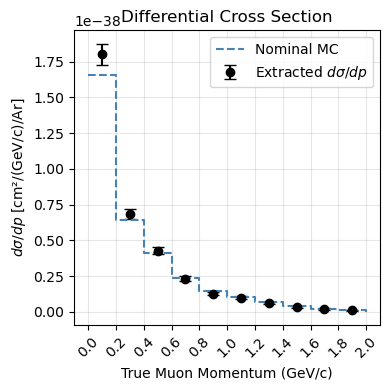

In [12]:
# ============================================================================
# STEP 9: TOY THROWING — TOTAL UNCERTAINTY
# ============================================================================

n_toys = 2000
print(f"Throwing {n_toys} toys...")

xsec_toys = np.zeros((n_toys, n_templates))
for k in range(n_toys):
    p = params_best + L_chol @ np.random.randn(n_params)
    p[:n_templates] = np.maximum(p[:n_templates], 1e-4)

    c_toy  = p[:n_templates]
    f_toy  = p[n_templates:n_templates+3]
    fw_toy = np.array([
        1+f_toy[0], 1+f_toy[0], 1+f_toy[0],
        1+f_toy[1], 1+f_toy[1], 1+f_toy[1], 1+f_toy[1],
        1+f_toy[2], 1+f_toy[2], 1+f_toy[2],
    ])
    N_sig_toy       = c_toy * fw_toy * N_true_gen
    xsec_toys[k, :] = N_sig_toy / (true_bin_widths * Phi * N_target)

xsec_mean = np.mean(xsec_toys, axis=0)
xsec_std  = np.std(xsec_toys,  axis=0)

print(f"\n{'Bin':>4}  {'p range':>14}  {'dσ/dp':>14}  {'±':>12}  {'Rel. unc.':>10}")
print("-" * 62)
for i in range(n_templates):
    rel = xsec_std[i] / xsec_mean[i] * 100
    print(f"  T{i+1:<2}  [{true_bin_edges[i]:.2f}, {true_bin_edges[i+1]:.2f}]  {xsec_mean[i]:>14.3e}  ±{xsec_std[i]:.3e}  {rel:>9.1f}%")

# ── Cross section plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 4))
ax.errorbar(true_centers, xsec_mean, yerr=xsec_std,
            fmt='ko', markersize=6, capsize=4, linewidth=1.5,
            label='Extracted $d\\sigma/dp$')
ax.step(true_bin_edges, np.append(N_true_gen / (true_bin_widths * Phi * N_target), 0),
        where='post', color='steelblue', linestyle='--', linewidth=1.5,
        label='Nominal MC')
ax.set_xlabel('True Muon Momentum (GeV/c)')
ax.set_ylabel('$d\\sigma/dp$ [cm²/(GeV/c)/Ar]')
ax.set_title('Differential Cross Section')
ax.set_xticks(true_bin_edges)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()